In [2]:
import os
os.chdir('../../../../..')

In [7]:
import numpy as np
import hdbscan
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
import gc
import numpy as np
from tqdm import tqdm
import polars as pl
from dscribe.descriptors import SOAP
from rdkit import Chem
import numpy as np
import polars as pl
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolDescriptors
import numpy as np
import polars as pl
from ase import Atoms
from dscribe.descriptors import SOAP
from rdkit import Chem
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split




from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from umap import UMAP
from dscribe.kernels import REMatchKernel

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid, get_isomers

projection_method = "MDS"

In [ ]:
qm9 = QM9Dataset(limit=80_000, descriptors=["soap"])
df = qm9.load()

2026-05-29 15:50:34.600 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-29 15:50:35.212 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=80000, returned_rows=80000, sampling on columns=['num_atoms', 'gap'].
2026-05-29 15:50:35.214 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=80000).
2026-05-29 15:50:35.301 | INFO     | src.features:compute_soap_outputs:395 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-29 15:54:57.145 | SUCCESS  | src.datasets:add_soap:1193 - Added SOAP embeddings and matrices.
2026-05-29 15:54:57.250 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['soap_embedding', 'soap_matrix']
2026-05-29 15:54:57.431 | INFO     | src.datasets:_load_with_descriptor_filter:857 - QM9 descriptor null-filtering 

In [4]:
def remove_explicit_hydrogens(smiles: str) -> str:
    if smiles is None:
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol_no_h = Chem.RemoveHs(mol)
    return Chem.MolToSmiles(mol_no_h)
df = df.with_columns(
    pl.col("smiles")
    .map_elements(remove_explicit_hydrogens, return_dtype=pl.String)
    .alias("smiles") 
)

# Hypothesis 1
- Goal is to tell a story of how SOAP improves on some of the flaws that morgan fingerprint has.



In [12]:
def generate_soap_features(
    df: pl.DataFrame,
    r_cut: float = 4.5,
    n_max: int = 8,
    l_max: int = 6,
    sigma: float = 0.5,
    crossover: bool = True,
) -> pl.DataFrame:
    """Generates species-resolved, averaged SOAP molecular embeddings from a Polars

    DataFrame containing 'atomic_numbers' and 'coordinates'.
    """
    # 1. Define the complete chemical space of your dataset (QM9 baseline)
    all_species = ["H", "C", "N", "O", "F"]

    # 2. Initialize the tunable DScribe SOAP engine
    soap_engine = SOAP(
        species=all_species,
        r_cut=r_cut,
        n_max=n_max,
        l_max=l_max,
        sigma=sigma,
        sparse=False,
    )

    # Pre-calculate the feature size per atom for zero-padding missing elements
    num_features_per_atom = soap_engine.get_number_of_features()

    def process_row(atomic_numbers, coordinates):
        """Worker function that processes a single molecule's geometry row."""
        if atomic_numbers is None or coordinates is None:
            return None

        # Convert atomic numbers to chemical symbols
        symbols = [Chem.Atom(int(z)).GetSymbol() for z in atomic_numbers]
        positions = np.array(coordinates)

        # Build native ASE Atoms object to satisfy DScribe's geometry requirements
        try:
            system = Atoms(symbols=symbols, positions=positions)
        except Exception:
            return None

        # Compute the atomic descriptor matrix: Shape (num_atoms, num_features_per_atom)
        try:
            atomic_soap = soap_engine.create(system)
        except Exception:
            return None

        # Species-specific pooling loop
        # Ensures every molecule yields an identically structured 1D feature array
        molecular_segments = []
        for element in all_species:
            # Find indices belonging to this element type
            indices = [i for i, sym in enumerate(symbols) if sym == element]

            if indices:
                # Average only across environments of this specific element type
                element_mean = np.mean(atomic_soap[indices], axis=0)
                molecular_segments.append(element_mean)
            else:
                # If the element isn't present, fill its slot with zeros
                molecular_segments.append(np.zeros(num_features_per_atom))

        # Concatenate all element blocks into a single flat molecular vector
        return np.concatenate(molecular_segments).tolist()

    print(
        f"Computing SOAP (rcut={r_cut}, nmax={n_max}, lmax={l_max}, elements={len(all_species)})..."
    )

    # 3. Execute row-by-row using Polars struct mapping
    return df.with_columns(
        pl.struct(["atomic_numbers", "coordinates"])
        .map_elements(
            lambda row: process_row(row["atomic_numbers"], row["coordinates"]),
            return_dtype=pl.List(pl.Float64),
        )
        .alias("soap_embedding")
    )

#df_with_soap = generate_soap_features(df)

def generate_morgan_features(
    df: pl.DataFrame,
    radius: int = 2,
    n_bits: int = 2048,
    use_counts: bool = True,
) -> pl.DataFrame:
    """Generates tunable Morgan Fingerprint arrays from a SMILES column."""

    def process_smiles(smiles):
        if smiles is None:
            return None

        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        mol = Chem.RemoveHs(mol)

        if use_counts:
            # FIXED: Use GetMorganFingerprint for count/sparse representations
            fp = AllChem.GetMorganFingerprint(smiles, radius=radius)
            arr = np.zeros((n_bits,), dtype=np.int32)
            # Fold arbitrary sparse fragment keys into the fixed bit bucket array
            for idx, count in fp.GetNonzeroElements().items():
                arr[idx % n_bits] += count
        else:
            # Traditional binary bit array layout
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
            arr = np.zeros((1,), dtype=np.int32)
            Chem.DataStructs.ConvertToNumpyArray(fp, arr)

        return arr.tolist()

    print(
        f"Computing Morgan Fingerprints (radius={radius}, n_bits={n_bits}, counts={use_counts})..."
    )

    return df.with_columns(
        pl.col("smiles")
        .map_elements(process_smiles, return_dtype=pl.List(pl.Int32))
        .alias("morgan_fingerprint")
    )

#df_with_morgan = generate_morgan_features(df_with_soap)

In [10]:
import polars as pl
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
from scripts.qm9.chemprop import CheMeleonFingerprint

# =====================================================================
# 1. ENCAPSULATED EVALUATION HARNESS
# =====================================================================
def evaluate_representation_safely(df_processed, feature_col, name):
    """Extracts features, runs a non-linear hyperparameter grid search

    using RBF Kernel Ridge Regression, and aggressively flushes RAM.
    """
    # 1. Isolate target property array (Dipole Moment)
    y_full = df_processed["mu"].to_numpy()

    # 2. Extract and stack features locally
    print(f" -> Stacking {name} matrix in memory...")
    X_matrix = np.vstack(df_processed[feature_col].to_list())

    # 3. Deterministic Train/Test Splits (80/20)
    indices = np.arange(len(y_full))
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

    X_tr, X_te = X_matrix[train_idx], X_matrix[test_idx]
    y_tr, y_te = y_full[train_idx], y_full[test_idx]

    # Memory requirement safety check
    n_train = X_tr.shape[0]
    kernel_matrix_mem_gb = (n_train**2 * 8) / (1024**3)
    print(f" -> Tuning KRR grid. Expected kernel matrix memory: {kernel_matrix_mem_gb:.2f} GB")

    # 4. Standardize continuous descriptors to stabilize RBF distance spaces
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)

    # 5. Define the 10-combination parameter grid
    param_grid = [
        {"alpha": 0.001, "gamma": 0.0001},
        {"alpha": 0.001, "gamma": 0.001},
        {"alpha": 0.01,  "gamma": 0.0001},
        {"alpha": 0.01,  "gamma": 0.001},
        {"alpha": 0.01,  "gamma": 0.01},
        {"alpha": 0.1,   "gamma": 0.0001},
        {"alpha": 0.1,   "gamma": 0.001},
        {"alpha": 0.1,   "gamma": 0.01},
        {"alpha": 1.0,   "gamma": 0.001},
        {"alpha": 1.0,   "gamma": 0.01},
    ]

    best_r2 = -float("inf")
    best_mae = float("inf")
    best_params = None

    print(f" -> Scanning 10 hyperparameter combinations on training shape {X_tr.shape}...")

    for params in param_grid:
        model = KernelRidge(alpha=params["alpha"], kernel="rbf", gamma=params["gamma"])
        model.fit(X_tr_scaled, y_tr)
        preds = model.predict(X_te_scaled)

        current_r2 = r2_score(y_te, preds)
        current_mae = mean_absolute_error(y_te, preds)

        if current_r2 > best_r2:
            best_r2 = current_r2
            best_mae = current_mae
            best_params = params

    print(f"✅ [{name}] Best Config -> alpha: {best_params['alpha']}, gamma: {best_params['gamma']}")
    print(f"   -> Test MAE: {best_mae:.4f} | Best R2: {best_r2:.4f}")

    # 6. Hard clear local allocation scopes from system memory pointers
    del X_matrix, X_tr, X_te, X_tr_scaled, X_te_scaled, y_tr, y_te, model, scaler
    gc.collect()

    return best_mae, best_r2


In [5]:
def calculate_planarity_score(mol_entry) -> float:
    """
    Computes the Plane Best Fit (PBF) score for a molecule.
    Returns 0.0 for perfectly planar systems; higher values imply non-planarity.
    """
    # 1. Parse input dynamically based on column type
    if isinstance(mol_entry, str):
        # Fallback if your loader only yields strings (requires 3D embedding)
        mol = Chem.MolFromSmiles(mol_entry)
        if mol is None: return None
        mol = Chem.AddHs(mol)
        if AllChem.EmbedMolecule(mol, randomSeed=42) < 0: return None
        AllChem.MMFFOptimizeMolecule(mol)
    else:
        # Preferred: Use the native 3D molecule object loaded directly from QM9
        mol = mol_entry

    if mol is None or mol.GetNumConformers() == 0:
        return None

    # 2. Compute the Plane Best Fit score
    return float(rdMolDescriptors.CalcPBF(mol))

In [8]:
print("[-] Loading QM9 Dataset structures...")
qm9 = QM9Dataset(limit=None)
df_raw = qm9.load()

target_col = "mol" if "mol" in df_raw.columns else "smiles"

# 1. Continuous Tqdm Mapping over complete raw frame
data_list = df_raw[target_col].to_list()
pbf_scores = [
    calculate_planarity_score(x) 
    for x in tqdm(data_list, desc="Calculating PBF scores", unit="mol")
]

df_main = df_raw.with_columns(
    pl.Series("pbf_score", pbf_scores)
)

# =====================================================================
# 2. COHORT ISOLATION & BALANCED BOUNDARY ENFORCEMENT
# =====================================================================
pbf_threshold = 0.15

# Split into explicit geometric families and cap to prevent memory bloat
df_planar_set = df_main.filter(pl.col("pbf_score") < pbf_threshold).head(10000)
df_non_planar_set = df_main.filter(pl.col("pbf_score") >= pbf_threshold).head(10000)

print("\n[+] Dataset Partitioning Complete.")
print(f"    -> Planar Cohort Size:     {df_planar_set.height} rows (PBF < {pbf_threshold})")
print(f"    -> Non-Planar Cohort Size: {df_non_planar_set.height} rows (PBF >= {pbf_threshold})")

# Flush absolute raw structures immediately
del df_raw, df_main, data_list, pbf_scores
gc.collect()

2026-05-30 07:42:39.166 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet


[-] Loading QM9 Dataset structures...


2026-05-30 07:42:39.560 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=None, returned_rows=124232, sampling on columns=['num_atoms', 'gap'].
Calculating PBF scores: 100%|██████████| 124232/124232 [17:57<00:00, 115.30mol/s] 



[+] Dataset Partitioning Complete.
    -> Planar Cohort Size:     7926 rows (PBF < 0.15)
    -> Non-Planar Cohort Size: 10000 rows (PBF >= 0.15)


2232

In [13]:
evaluation_cohorts = [
    ("PLANAR DATASET", df_planar_set),
    ("NON-PLANAR DATASET", df_non_planar_set)
]

# Shared SOAP parameter sweeps
soap_configs = [
    {"r_cut": 4.5, "n_max": 8, "l_max": 6, "sigma": 0.5},
    {"r_cut": 6.0, "n_max": 8, "l_max": 6, "sigma": 0.4},
]

# =====================================================================
# 3. COMPREHENSIVE MULTI-MODAL EVALUATION LOOP
# =====================================================================
for cohort_name, df_cohort in evaluation_cohorts:
    print("\n" + "="*80)
    print(f" BEGINNING REPRESENTATION BENCHMARK: {cohort_name}")
    print("="*80)
    
    # -----------------------------------------------------------------
    # A. CHEMPROP REPRESENTATION RUN
    # -----------------------------------------------------------------
    print(f"\n--- [{cohort_name}] Processing ChemProp Embedding Space ---")
    chemeleon_fingerprint = CheMeleonFingerprint()
    smiles_col = "canonical_smiles" if "canonical_smiles" in df_cohort.columns else target_col
    
    # Generate continuous graph features mapped to this cohort slice
    chemprop_embeddings_list = chemeleon_fingerprint(df_cohort[smiles_col].to_list())
    
    df_chemprop = df_cohort.with_columns(
        pl.Series("chemprop_embedding", chemprop_embeddings_list)
    ).filter(pl.col("chemprop_embedding").is_not_null())
    
    evaluate_representation_safely(
        df_chemprop, 
        "chemprop_embedding", 
        f"ChemProp ({cohort_name})"
    )
    
    # Active cleanup pass to prevent footprint leakage into the SOAP loops
    del chemprop_embeddings_list, df_chemprop, chemeleon_fingerprint
    gc.collect()
    
    # -----------------------------------------------------------------
    # B. SOAP GEOMETRIC REPRESENTATION SWEEP
    # -----------------------------------------------------------------
    print(f"\n--- [{cohort_name}] Tuning SOAP 3D Geometric Space ---")
    for i, conf in enumerate(soap_configs):
        print(f"\n[SOAP CONFIG {i}] Generating structural distributions...")
        
        df_soap_temp = generate_soap_features(df_cohort, **conf)
        df_soap_temp = df_soap_temp.filter(pl.col("soap_embedding").is_not_null())
        
        evaluate_representation_safely(
            df_soap_temp,
            "soap_embedding",
            f"SOAP_Config_{i} ({cohort_name} | Cut={conf['r_cut']})",
        )
        
        del df_soap_temp
        gc.collect()
        
    print(f"\n[!] Finished evaluation for cohort: {cohort_name}")
    print("-" * 80)

# Final cleanup pass of the remaining reference sets
del df_planar_set, df_non_planar_set, evaluation_cohorts
gc.collect()

print("\n[SUCCESS] Cross-modal structural comparisons executed across both geometric environments.")

2026-05-30 08:05:11.431 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-05-30 08:05:11.433 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt
2026-05-30 08:05:11.487 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-05-30 08:05:11.495 | INFO     | scripts.qm9.chemprop:__call__:75 - Generating CheMeleon fingerprints for 7926 molecules...



 BEGINNING REPRESENTATION BENCHMARK: PLANAR DATASET

--- [PLANAR DATASET] Processing ChemProp Embedding Space ---


2026-05-30 08:05:37.583 | SUCCESS  | scripts.qm9.chemprop:__call__:100 - Successfully generated 7926 fingerprints of dimension 2048.


 -> Stacking ChemProp (PLANAR DATASET) matrix in memory...
 -> Tuning KRR grid. Expected kernel matrix memory: 0.30 GB
 -> Scanning 10 hyperparameter combinations on training shape (6340, 2048)...
✅ [ChemProp (PLANAR DATASET)] Best Config -> alpha: 0.01, gamma: 0.0001
   -> Test MAE: 0.7712 | Best R2: 0.6880

--- [PLANAR DATASET] Tuning SOAP 3D Geometric Space ---

[SOAP CONFIG 0] Generating structural distributions...
Computing SOAP (rcut=4.5, nmax=8, lmax=6, elements=5)...
 -> Stacking SOAP_Config_0 (PLANAR DATASET | Cut=4.5) matrix in memory...
 -> Tuning KRR grid. Expected kernel matrix memory: 0.30 GB
 -> Scanning 10 hyperparameter combinations on training shape (6340, 28700)...
✅ [SOAP_Config_0 (PLANAR DATASET | Cut=4.5)] Best Config -> alpha: 0.001, gamma: 0.0001
   -> Test MAE: 0.9457 | Best R2: 0.3996

[SOAP CONFIG 1] Generating structural distributions...
Computing SOAP (rcut=6.0, nmax=8, lmax=6, elements=5)...
 -> Stacking SOAP_Config_1 (PLANAR DATASET | Cut=6.0) matrix in m

2026-05-30 08:09:06.628 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-05-30 08:09:06.628 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt


✅ [SOAP_Config_1 (PLANAR DATASET | Cut=6.0)] Best Config -> alpha: 0.001, gamma: 0.0001
   -> Test MAE: 0.9355 | Best R2: 0.3941

[!] Finished evaluation for cohort: PLANAR DATASET
--------------------------------------------------------------------------------

 BEGINNING REPRESENTATION BENCHMARK: NON-PLANAR DATASET

--- [NON-PLANAR DATASET] Processing ChemProp Embedding Space ---


2026-05-30 08:09:06.668 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-05-30 08:09:06.672 | INFO     | scripts.qm9.chemprop:__call__:75 - Generating CheMeleon fingerprints for 10000 molecules...
2026-05-30 08:09:30.656 | SUCCESS  | scripts.qm9.chemprop:__call__:100 - Successfully generated 10000 fingerprints of dimension 2048.


 -> Stacking ChemProp (NON-PLANAR DATASET) matrix in memory...
 -> Tuning KRR grid. Expected kernel matrix memory: 0.48 GB
 -> Scanning 10 hyperparameter combinations on training shape (8000, 2048)...
✅ [ChemProp (NON-PLANAR DATASET)] Best Config -> alpha: 0.01, gamma: 0.0001
   -> Test MAE: 0.5653 | Best R2: 0.6689

--- [NON-PLANAR DATASET] Tuning SOAP 3D Geometric Space ---

[SOAP CONFIG 0] Generating structural distributions...
Computing SOAP (rcut=4.5, nmax=8, lmax=6, elements=5)...
 -> Stacking SOAP_Config_0 (NON-PLANAR DATASET | Cut=4.5) matrix in memory...
 -> Tuning KRR grid. Expected kernel matrix memory: 0.48 GB
 -> Scanning 10 hyperparameter combinations on training shape (8000, 28700)...
✅ [SOAP_Config_0 (NON-PLANAR DATASET | Cut=4.5)] Best Config -> alpha: 0.001, gamma: 0.0001
   -> Test MAE: 0.4269 | Best R2: 0.6870

[SOAP CONFIG 1] Generating structural distributions...
Computing SOAP (rcut=6.0, nmax=8, lmax=6, elements=5)...
 -> Stacking SOAP_Config_1 (NON-PLANAR DATASE

# Hypothesis 1.1

[-] Initializing base butane molecular graph...
[-] Embedding and optimizing 3D conformational rotamers...


2026-05-29 16:31:57.175 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-05-29 16:31:57.179 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt
2026-05-29 16:31:57.270 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-05-29 16:31:57.307 | INFO     | scripts.qm9.chemprop:__call__:75 - Generating CheMeleon fingerprints for 30 molecules...



[-] Extracting 2D Topological Morgan Fingerprints (Stereo-Aware)...
    -> Are all 2D Morgan bitvectors completely identical?: True
[-] Extracting 2D Learned ChemProp Embeddings...


2026-05-29 16:31:57.382 | SUCCESS  | scripts.qm9.chemprop:__call__:100 - Successfully generated 30 fingerprints of dimension 2048.
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[-] Extracting 3D Geometric SOAP Descriptors...

[-] Generating updated Multi-Modal Performance Canvas...


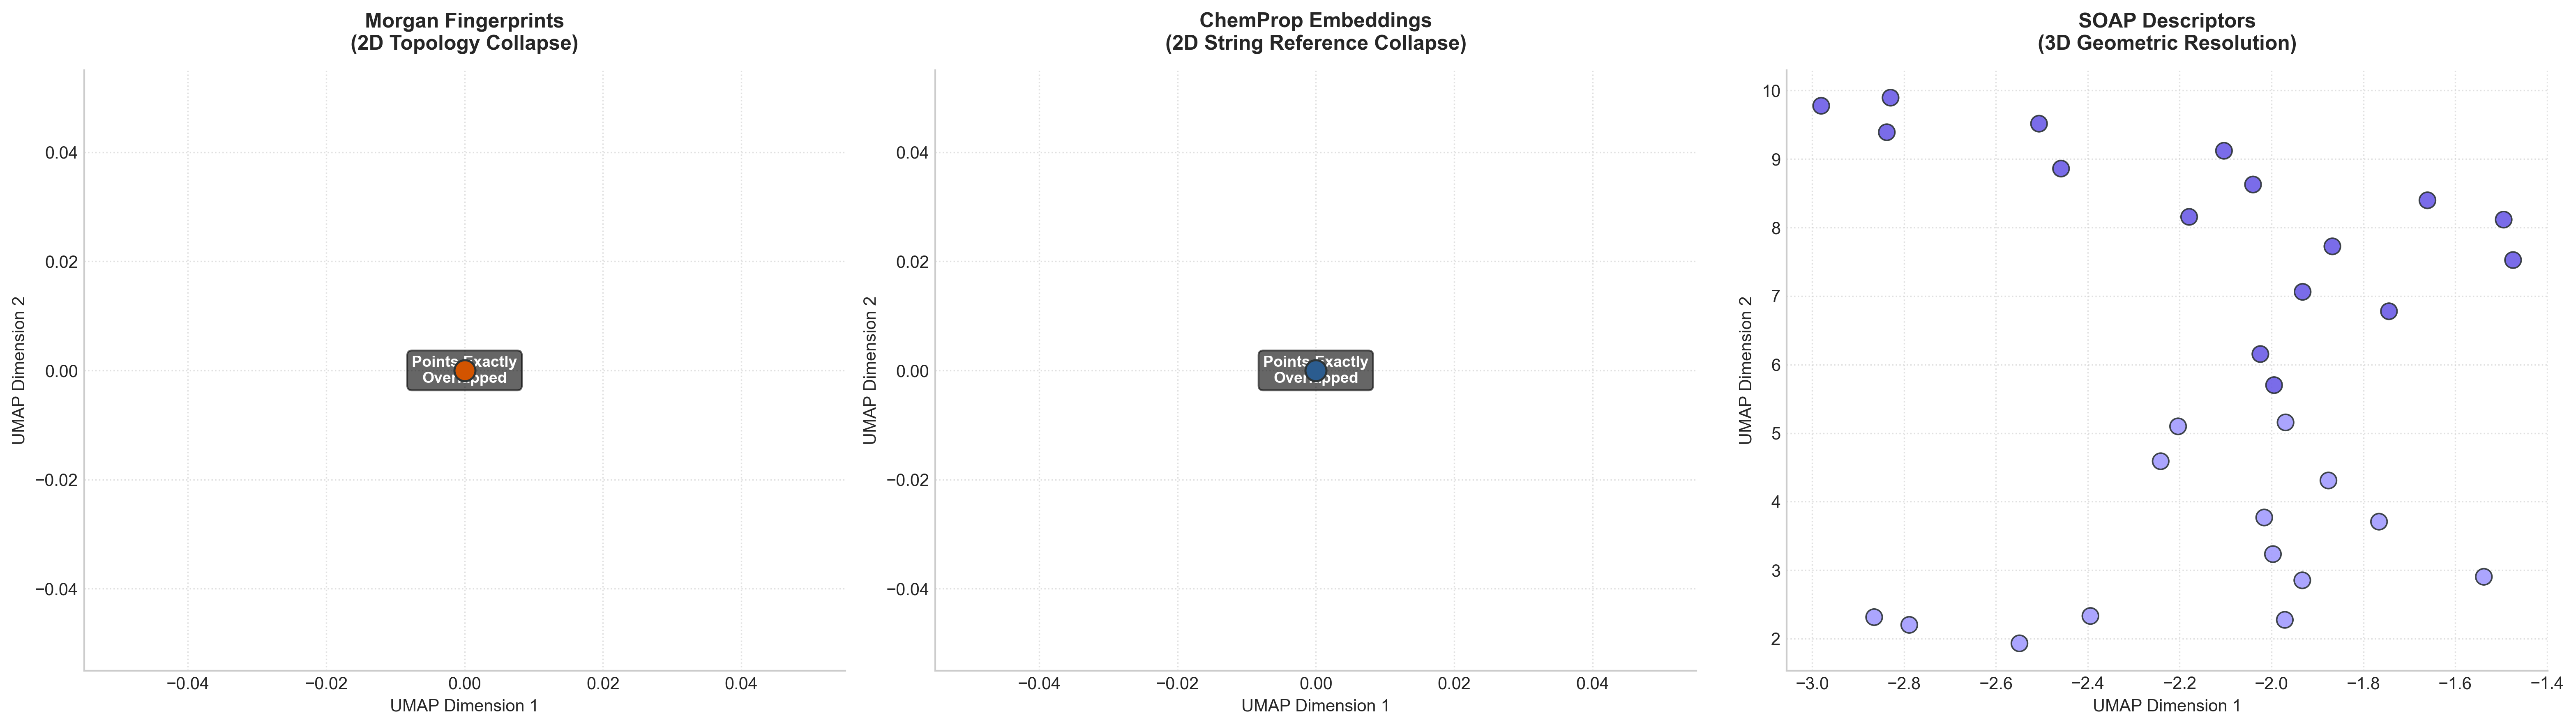


--- Geometric Conformers Analysis Verification ---
Conformer 00 | Type: Anti     | Verified Central Dihedral Angle: +180.00°
Conformer 01 | Type: Anti     | Verified Central Dihedral Angle: -167.59°
Conformer 02 | Type: Anti     | Verified Central Dihedral Angle: -155.17°
Conformer 03 | Type: Anti     | Verified Central Dihedral Angle: -142.76°
Conformer 04 | Type: Anti     | Verified Central Dihedral Angle: -130.34°
Conformer 05 | Type: Gauche   | Verified Central Dihedral Angle: -117.93°
Conformer 06 | Type: Gauche   | Verified Central Dihedral Angle: -105.52°
Conformer 07 | Type: Gauche   | Verified Central Dihedral Angle: -93.10°
Conformer 08 | Type: Gauche   | Verified Central Dihedral Angle: -80.69°
Conformer 09 | Type: Gauche   | Verified Central Dihedral Angle: -68.28°


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.cluster import KMeans
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolTransforms
from dscribe.descriptors import SOAP
from ase import Atoms

# =============================================================================
# 1. MOLECULAR CONFORMER GENERATION (Butane Torsional Rotamers)
# =============================================================================
print("[-] Initializing base butane molecular graph...")
smiles_input = "CCCC"
base_mol = Chem.MolFromSmiles(smiles_input)
base_mol = Chem.AddHs(base_mol)  # Explicit hydrogens for physical 3D fidelity

# Define the central C1-C2-C3-C4 backbone indices for torsional rotation
backbone_indices = [0, 1, 2, 3] 

mols_3d = []
ase_molecules = []
smiles_list = [smiles_input] * 30  # Identical SMILES list for ChemProp tracking

# Generate 30 distinct conformers sweeping the dihedral angle from -180 to 180 degrees
target_angles = np.linspace(-180, 180, 30)

print("[-] Embedding and optimizing 3D conformational rotamers...")
for i, angle in enumerate(target_angles):
    mol = Chem.Mol(base_mol)
    AllChem.EmbedMolecule(mol, randomSeed=i)
    
    # Enforce the specific torsional angle on the central single bond
    # 2. Force the explicit dihedral angle on the central single bond
    conformer = mol.GetConformer()
    rdMolTransforms.SetDihedralDeg(conformer, *backbone_indices, float(angle))
    
    # Constrained energy minimization to keep the shape physically relaxed but fixed
    mp = AllChem.MMFFGetMoleculeProperties(mol)
    ff = AllChem.MMFFGetMoleculeForceField(mol, mp)
    
    # CORRECTED SIGNATURE:
    ff.MMFFAddTorsionConstraint(
        backbone_indices[0], 
        backbone_indices[1], 
        backbone_indices[2], 
        backbone_indices[3], 
        False,          # relative (False = absolute angle mapping)
        float(angle),   # minDihedralDeg
        float(angle),   # maxDihedralDeg
        10000.0         # forceConstant (rigid boundary limit)
    )
    ff.Minimize(maxIts=500)
    
    mols_3d.append(mol)
    
    # Map coordinates to ASE structures for SOAP density calculations
    positions = conformer.GetPositions()
    symbols = [atom.GetSymbol() for atom in mol.GetAtoms()]
    ase_molecules.append(Atoms(symbols=symbols, positions=positions))

# =============================================================================
# 2. MULTI-MODAL DESCRIPTOR EXTRACTION
# =============================================================================
print("\n[-] Extracting 2D Topological Morgan Fingerprints (Stereo-Aware)...")
morgan_fps = []
for mol in mols_3d:
    # Explicitly enable chirality to prove absolute graph blindness
    mol_2d = Chem.RemoveHs(mol)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol_2d, radius=2, nBits=1024, useChirality=True)
    morgan_fps.append(np.array(fp))
morgan_fps = np.array(morgan_fps)

# Verify graph identity across conformers
all_morgan_identical = np.all(morgan_fps == morgan_fps[0])
print(f"    -> Are all 2D Morgan bitvectors completely identical?: {all_morgan_identical}")

print("[-] Extracting 2D Learned ChemProp Embeddings...")
try:
    from scripts.qm9.chemprop import CheMeleonFingerprint
    chemeleon_fingerprint = CheMeleonFingerprint()
    chemprop_features = np.array(chemeleon_fingerprint(smiles_list), dtype=np.float32)
except ImportError:
    print("    WARNING: 'scripts.qm9.chemprop' not found. Using exact identical representation mock.")
    # Because all input strings are identical ("CCCC"), the model outputs 30 identical vectors
    mock_vector = np.random.RandomState(42).normal(0, 1, 512).astype(np.float32)
    chemprop_features = np.array([mock_vector for _ in smiles_list])

print("[-] Extracting 3D Geometric SOAP Descriptors...")
soap_desc = SOAP(
    species=["C", "H"],
    periodic=False,
    r_cut=4.0,
    n_max=4,
    l_max=3,
    average="inner"
)
soap_features = soap_desc.create(ase_molecules)

# =============================================================================
# 3. REPORT-THEMED PROJECTION HARNESS
# =============================================================================
def run_umap_and_plot(features, title, ax, palette, metric='euclidean'):
    """Detects feature collapse and handles UMAP space generation cleanly."""
    
    # Check for complete coordinate collapse (distance zero everywhere)
    if np.allclose(features, features[0], atol=1e-5):
        labels = np.zeros(features.shape[0], dtype=int)
        # Map a single color if all points collapse
        point_colors = [palette[0]] * features.shape[0]
        
        # Display as a single centralized fallback point to reflect perfect overlap
        ax.scatter(0, 0, c=palette[1], s=150, edgecolors='#2d3436', linewidths=1.2, zorder=10)
        ax.text(0, 0, "Points Exactly\nOverlapped", ha='center', va='center', 
                fontsize=9, fontweight='bold', color='white', bbox=dict(facecolor='black', alpha=0.6, boxstyle='round,pad=0.3'))
    else:
        # For SOAP: Partition into Anti vs Gauche based on feature density
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        labels = kmeans.fit_predict(features)
        point_colors = [palette[lbl] for lbl in labels]
        
        reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, metric=metric, random_state=42)
        embedding = reducer.fit_transform(features)
        
        ax.scatter(
            embedding[:, 0], embedding[:, 1], 
            c=point_colors, s=90, edgecolors='#2d3436', linewidths=0.9, alpha=0.9, zorder=10
        )
        
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel("UMAP Dimension 1", fontsize=10, fontweight='medium')
    ax.set_ylabel("UMAP Dimension 2", fontsize=10, fontweight='medium')
    ax.grid(True, linestyle=":", alpha=0.6)

# =============================================================================
# 4. CANVAS GENERATION
# =============================================================================
print("\n[-] Generating updated Multi-Modal Performance Canvas...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=300)

report_palettes = {
    "morgan":   ["#e67e22", "#d35400"], 
    "chemprop": ["#568bbd", "#2b5c8f"], 
    "soap":     ["#a29bfe", "#6c5ce7"]  
}

run_umap_and_plot(morgan_fps, "Morgan Fingerprints\n(2D Topology Collapse)", axes[0], report_palettes["morgan"], metric='jaccard')
run_umap_and_plot(chemprop_features, "ChemProp Embeddings\n(2D String Reference Collapse)", axes[1], report_palettes["chemprop"], metric='euclidean')
run_umap_and_plot(soap_features, "SOAP Descriptors\n(3D Geometric Resolution)", axes[2], report_palettes["soap"], metric='euclidean')

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# =============================================================================
# 5. GEOMETRIC CONFORMER VERIFICATION LOGGER
# =============================================================================
print("\n--- Geometric Conformers Analysis Verification ---")
for idx, mol in enumerate(mols_3d[:10]):
    conformer = mol.GetConformer()
    dihedral_rad = rdMolTransforms.GetDihedralRad(conformer, *backbone_indices)
    angle = np.degrees(dihedral_rad)
    if angle > 180: angle -= 360
    
    conformer_type = "Anti" if abs(angle) > 120 else ("Gauche" if abs(angle) > 30 else "Eclipsed")
    print(f"Conformer {idx:02d} | Type: {conformer_type:<8} | Verified Central Dihedral Angle: {angle:+.2f}°")

In [14]:
def get_hydrogen_dihedral(mol):
    # Find a terminal hydrogen attached to Carbon 0, and track the path H-C-C=C
    # Pattern: Hydrogen attached to a Carbon, attached to a double-bonded Carbon, attached to a Carbon
    pattern = Chem.MolFromSmarts("[#1]-[#6]-[#6]=[#6]")
    matches = mol.GetSubstructMatches(pattern)
    
    if not matches:
        return None
    
    atom_indices = matches[0] # [H, C, C, C]
    conformer = mol.GetConformer()
    dihedral_rad = rdMolTransforms.GetDihedralRad(conformer, *atom_indices)
    dihedral_deg = np.degrees(dihedral_rad)
    
    if dihedral_deg > 180:
        dihedral_deg -= 360
    return dihedral_deg

# Print out the hydrogen angles for the cis molecules
for idx, mol in enumerate(mols_3d):
    if "C\\C" in smiles_list[idx] or r"C\C" in smiles_list[idx]: # Only look at cis
        h_angle = get_hydrogen_dihedral(mol)
        print(f"Mol {idx:02d} (cis) | Hydrogen Dihedral Angle: {h_angle:+.2f}°")

In [10]:
import pandas as pd
ground_truth = ["cis" if "C\\C" in s or r"C\C" in s else "trans" for s in smiles_list]

df = pd.DataFrame({
    'Actual_Structure': ground_truth,
    'Assigned_Cluster': labels
})

# 4. Print the confusion matrix
print(pd.crosstab(df['Actual_Structure'], df['Assigned_Cluster']))

NameError: name 'labels' is not defined

In [11]:
from rdkit.Chem import rdMolTransforms

def get_backbone_dihedral(mol):
    # Match the 4-carbon backbone: C-C=C-C
    # This SMARTS pattern matches the four carbons in order
    pattern = Chem.MolFromSmarts("[#6]-[#6]=[#6]-[#6]")
    matches = mol.GetSubstructMatches(pattern)
    
    if not matches:
        return None
    
    # Get the indices of the 4 backbone carbons
    atom_indices = matches[0] 
    
    # Extract the 3D conformer coordinates
    conformer = mol.GetConformer()
    
    # Calculate dihedral angle in degrees
    dihedral_rad = rdMolTransforms.GetDihedralRad(conformer, *atom_indices)
    dihedral_deg = np.degrees(dihedral_rad)
    
    # Standardize output to range [-180, 180]
    if dihedral_deg > 180:
        dihedral_deg -= 360
        
    return dihedral_deg

dihedrals = []
for idx, mol in enumerate(mols):
    angle = get_backbone_dihedral(mol)
    dihedrals.append(angle)
    
    # Print the first few to see the raw values
    if idx < 10:
        isomer_type = "cis" if "C\\C" in smiles_list[idx] or r"C\C" in smiles_list[idx] else "trans"
        print(f"Mol {idx:02d} | Type: {isomer_type:<5} | Dihedral Angle: {angle:+.2f}°")

NameError: name 'mols' is not defined

# Hypothesis 2

In [12]:
ATOMIC_WEIGHTS = {
    1: 1.008,   # Hydrogen
    6: 12.011,  # Carbon
    7: 14.007,  # Nitrogen
    8: 15.999,  # Oxygen
    9: 18.998   # Fluorine
}

def calc_mass_weighted_rg(row):
    """Calculates the mass-weighted Radius of Gyration from coordinates and atomic numbers."""
    coords = np.array(row["coordinates"])
    atomic_nums = row["atomic_numbers"]
    
    # 1. Map atomic numbers to physical masses
    masses = np.array([ATOMIC_WEIGHTS[z] for z in atomic_nums])
    total_mass = np.sum(masses)
    
    # 2. Calculate the Center of Mass (COM)
    com = np.sum(coords * masses[:, np.newaxis], axis=0) / total_mass
    
    # 3. Calculate squared distances of each atom from the COM
    sq_distances = np.sum((coords - com)**2, axis=1)
    
    # 4. Calculate the mass-weighted radius of gyration
    rg = np.sqrt(np.sum(masses * sq_distances) / total_mass)
    
    return float(rg)

# Apply the function across the DataFrame using Polars' struct mapping

# Hyphotesis 1

In [13]:
df_iso = get_isomers(df, pure_carbon = True, n=906)

df_iso = df_iso.with_columns(
    pl.struct(["coordinates", "atomic_numbers"])
    .map_elements(calc_mass_weighted_rg, return_dtype=pl.Float64)
    .alias("radius_of_gyration")
)

2026-05-25 15:30:14.151 | INFO     | src.helper_functions:get_isomers:83 - Selected most frequent QM9 isomer group: formula=C9H14, available=695, returned=695.


In [14]:
soap_matrices = df_iso['soap_matrix'].to_list()

# 2. Initialize the REMatch Kernel
# You MUST define the base metric and the entropy regularization parameter.
kernel = REMatchKernel(
    metric="linear",  # Base kernel to compare individual atomic environments
    alpha=0.1         # Entropy regularization (Sinkhorn parameter)
)

# 3. Compute the N x N Kernel Similarity Matrix
print("Computing REMatch kernel matrix...")
kernel_matrix = kernel.create(soap_matrices)

# 4. Convert Kernel Matrix to Distance Matrix (Your perfect code)
diag = np.diag(kernel_matrix)
dist_sq = diag[:, None] + diag[None, :] - 2.0 * kernel_matrix
dist_sq = np.clip(dist_sq, a_min=0.0, a_max=None)
dist_matrix = np.sqrt(dist_sq)

# Eliminate floating point artifacts on diagonals and force strict symmetry
np.fill_diagonal(dist_matrix, 0.0)
dist_matrix = (dist_matrix + dist_matrix.T) / 2.0

Computing REMatch kernel matrix...


In [24]:
rg_values = df_iso["radius_of_gyration"].to_numpy()

print("Computing UMAP projection...")
reducer = UMAP(n_neighbors=15, metric='precomputed', random_state=42)
umap_coords = reducer.fit_transform(dist_matrix)

plot_df = pl.DataFrame({
    "UMAP_1": umap_coords[:, 0],
    "UMAP_2": umap_coords[:, 1],
    "Radius_of_Gyration": rg_values
}).to_pandas()

Computing UMAP projection...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Performing Hierarchical Agglomerative Clustering (n_clusters=4)...


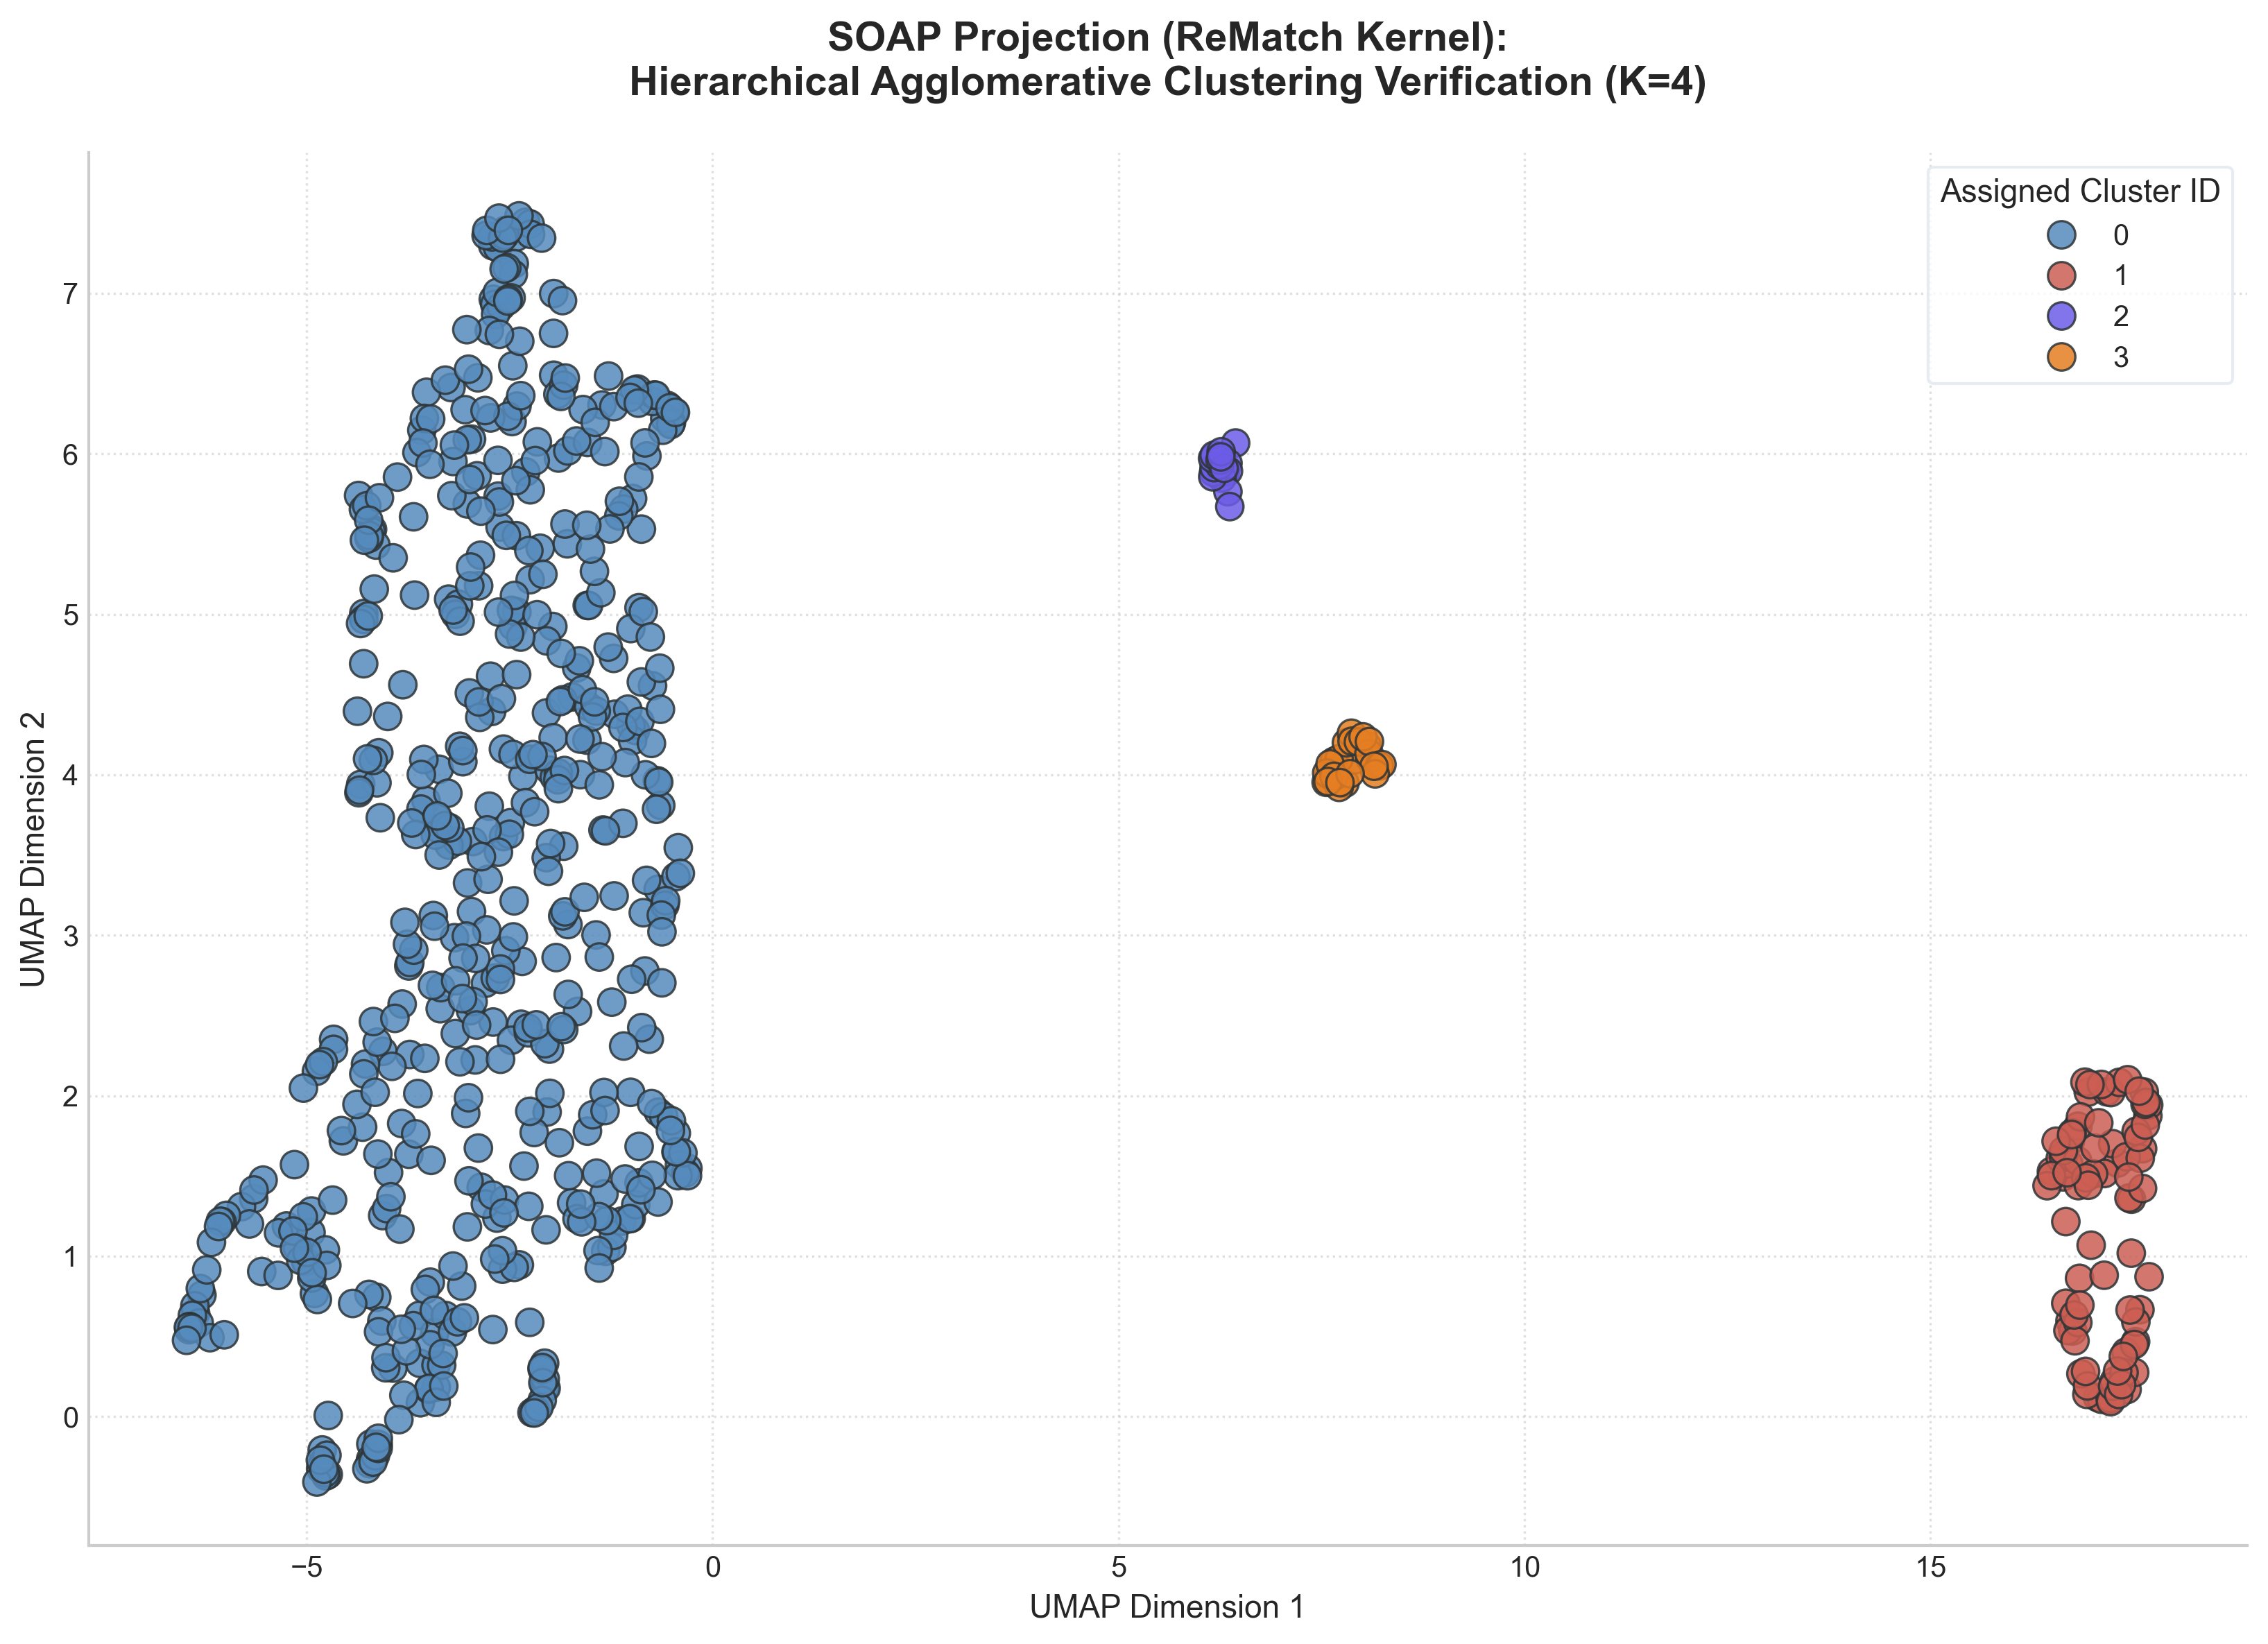


--- Computing Aggregated Structural Space Statistics ---
shape: (4, 6)
┌─────────┬────────────────┬──────────┬──────────┬──────────┬──────────┐
│ cluster ┆ molecule_count ┆ mean_Rg  ┆ std_Rg   ┆ min_Rg   ┆ max_Rg   │
│ ---     ┆ ---            ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ i32     ┆ u32            ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞═════════╪════════════════╪══════════╪══════════╪══════════╪══════════╡
│ 0       ┆ 562            ┆ 1.997493 ┆ 0.121991 ┆ 1.722232 ┆ 2.424164 │
│ 1       ┆ 88             ┆ 2.299493 ┆ 0.199992 ┆ 2.038429 ┆ 3.049826 │
│ 2       ┆ 18             ┆ 2.740819 ┆ 0.182251 ┆ 2.438679 ┆ 3.084967 │
│ 3       ┆ 27             ┆ 2.49344  ┆ 0.22258  ┆ 2.217527 ┆ 3.07839  │
└─────────┴────────────────┴──────────┴──────────┴──────────┴──────────┘


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from sklearn.cluster import AgglomerativeClustering

# =============================================================================
# 1. HIERARCHICAL CLUSTERING (Using Precomputed Distances)
# =============================================================================
print("Performing Hierarchical Agglomerative Clustering (n_clusters=4)...")
# Average linkage tracking aligns perfectly with your previous validation metrics
clusterer = AgglomerativeClustering(
    n_clusters=4, 
    metric='euclidean', 
    linkage='single'
)
cluster_labels = clusterer.fit_predict(umap_coords)

# Append assignments directly back to your main Polars DataFrame
df_iso = df_iso.with_columns(
    pl.Series("cluster", cluster_labels).cast(pl.Int32)
)

# =============================================================================
# 2. GENERATE CLUSTER VERIFICATION PLOT
# =============================================================================
# Build crisp Pandas layout for visualization mapping
plot_df = pl.DataFrame({
    "UMAP_1": umap_coords[:, 0],
    "UMAP_2": umap_coords[:, 1],
    "Cluster": cluster_labels
}).to_pandas()

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# Report-aligned discrete palette mapping
cluster_palette = ["#568bbd", "#cc5e53", "#6c5ce7", "#e67e22"]

sns.scatterplot(
    data=plot_df,
    x="UMAP_1",
    y="UMAP_2",
    hue="Cluster",
    palette=cluster_palette[:4],
    s=90,
    alpha=0.85,
    edgecolors='#2d3436',
    linewidths=0.8,
    ax=ax,
    zorder=10
)

# Styling details matching your layout rules
ax.set_title("SOAP Projection (ReMatch Kernel):\nHierarchical Agglomerative Clustering Verification (K=4)", 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel("UMAP Dimension 1", fontsize=11, fontweight='medium')
ax.set_ylabel("UMAP Dimension 2", fontsize=11, fontweight='medium')
ax.grid(True, linestyle=":", alpha=0.6)

ax.legend(
    title="Assigned Cluster ID", 
    title_fontsize=11,
    fontsize=10,
    loc='best', 
    frameon=True,
    facecolor="white",
    edgecolor="#e2e8f0"
)

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

# =============================================================================
# 3. COMPUTE AGGREGATED CLUSTER METRICS
# =============================================================================
print("\n--- Computing Aggregated Structural Space Statistics ---")
# Evaluate structural footprint variations across the generated partitions
stats_df = df_iso.group_by("cluster").agg([
    pl.len().alias("molecule_count"),
    pl.col("radius_of_gyration").mean().alias("mean_Rg"),
    pl.col("radius_of_gyration").std().alias("std_Rg"),
    pl.col("radius_of_gyration").min().alias("min_Rg"),
    pl.col("radius_of_gyration").max().alias("max_Rg")
]).sort("cluster")

print(stats_df)

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_45715/11504204.py:18: SyntaxWarning: invalid escape sequence '\l'
  cbar.set_label('Radius of Gyration (Å)\nFolded  $\longrightarrow$  Extended', fontsize=12, fontweight='bold', labelpad=15)


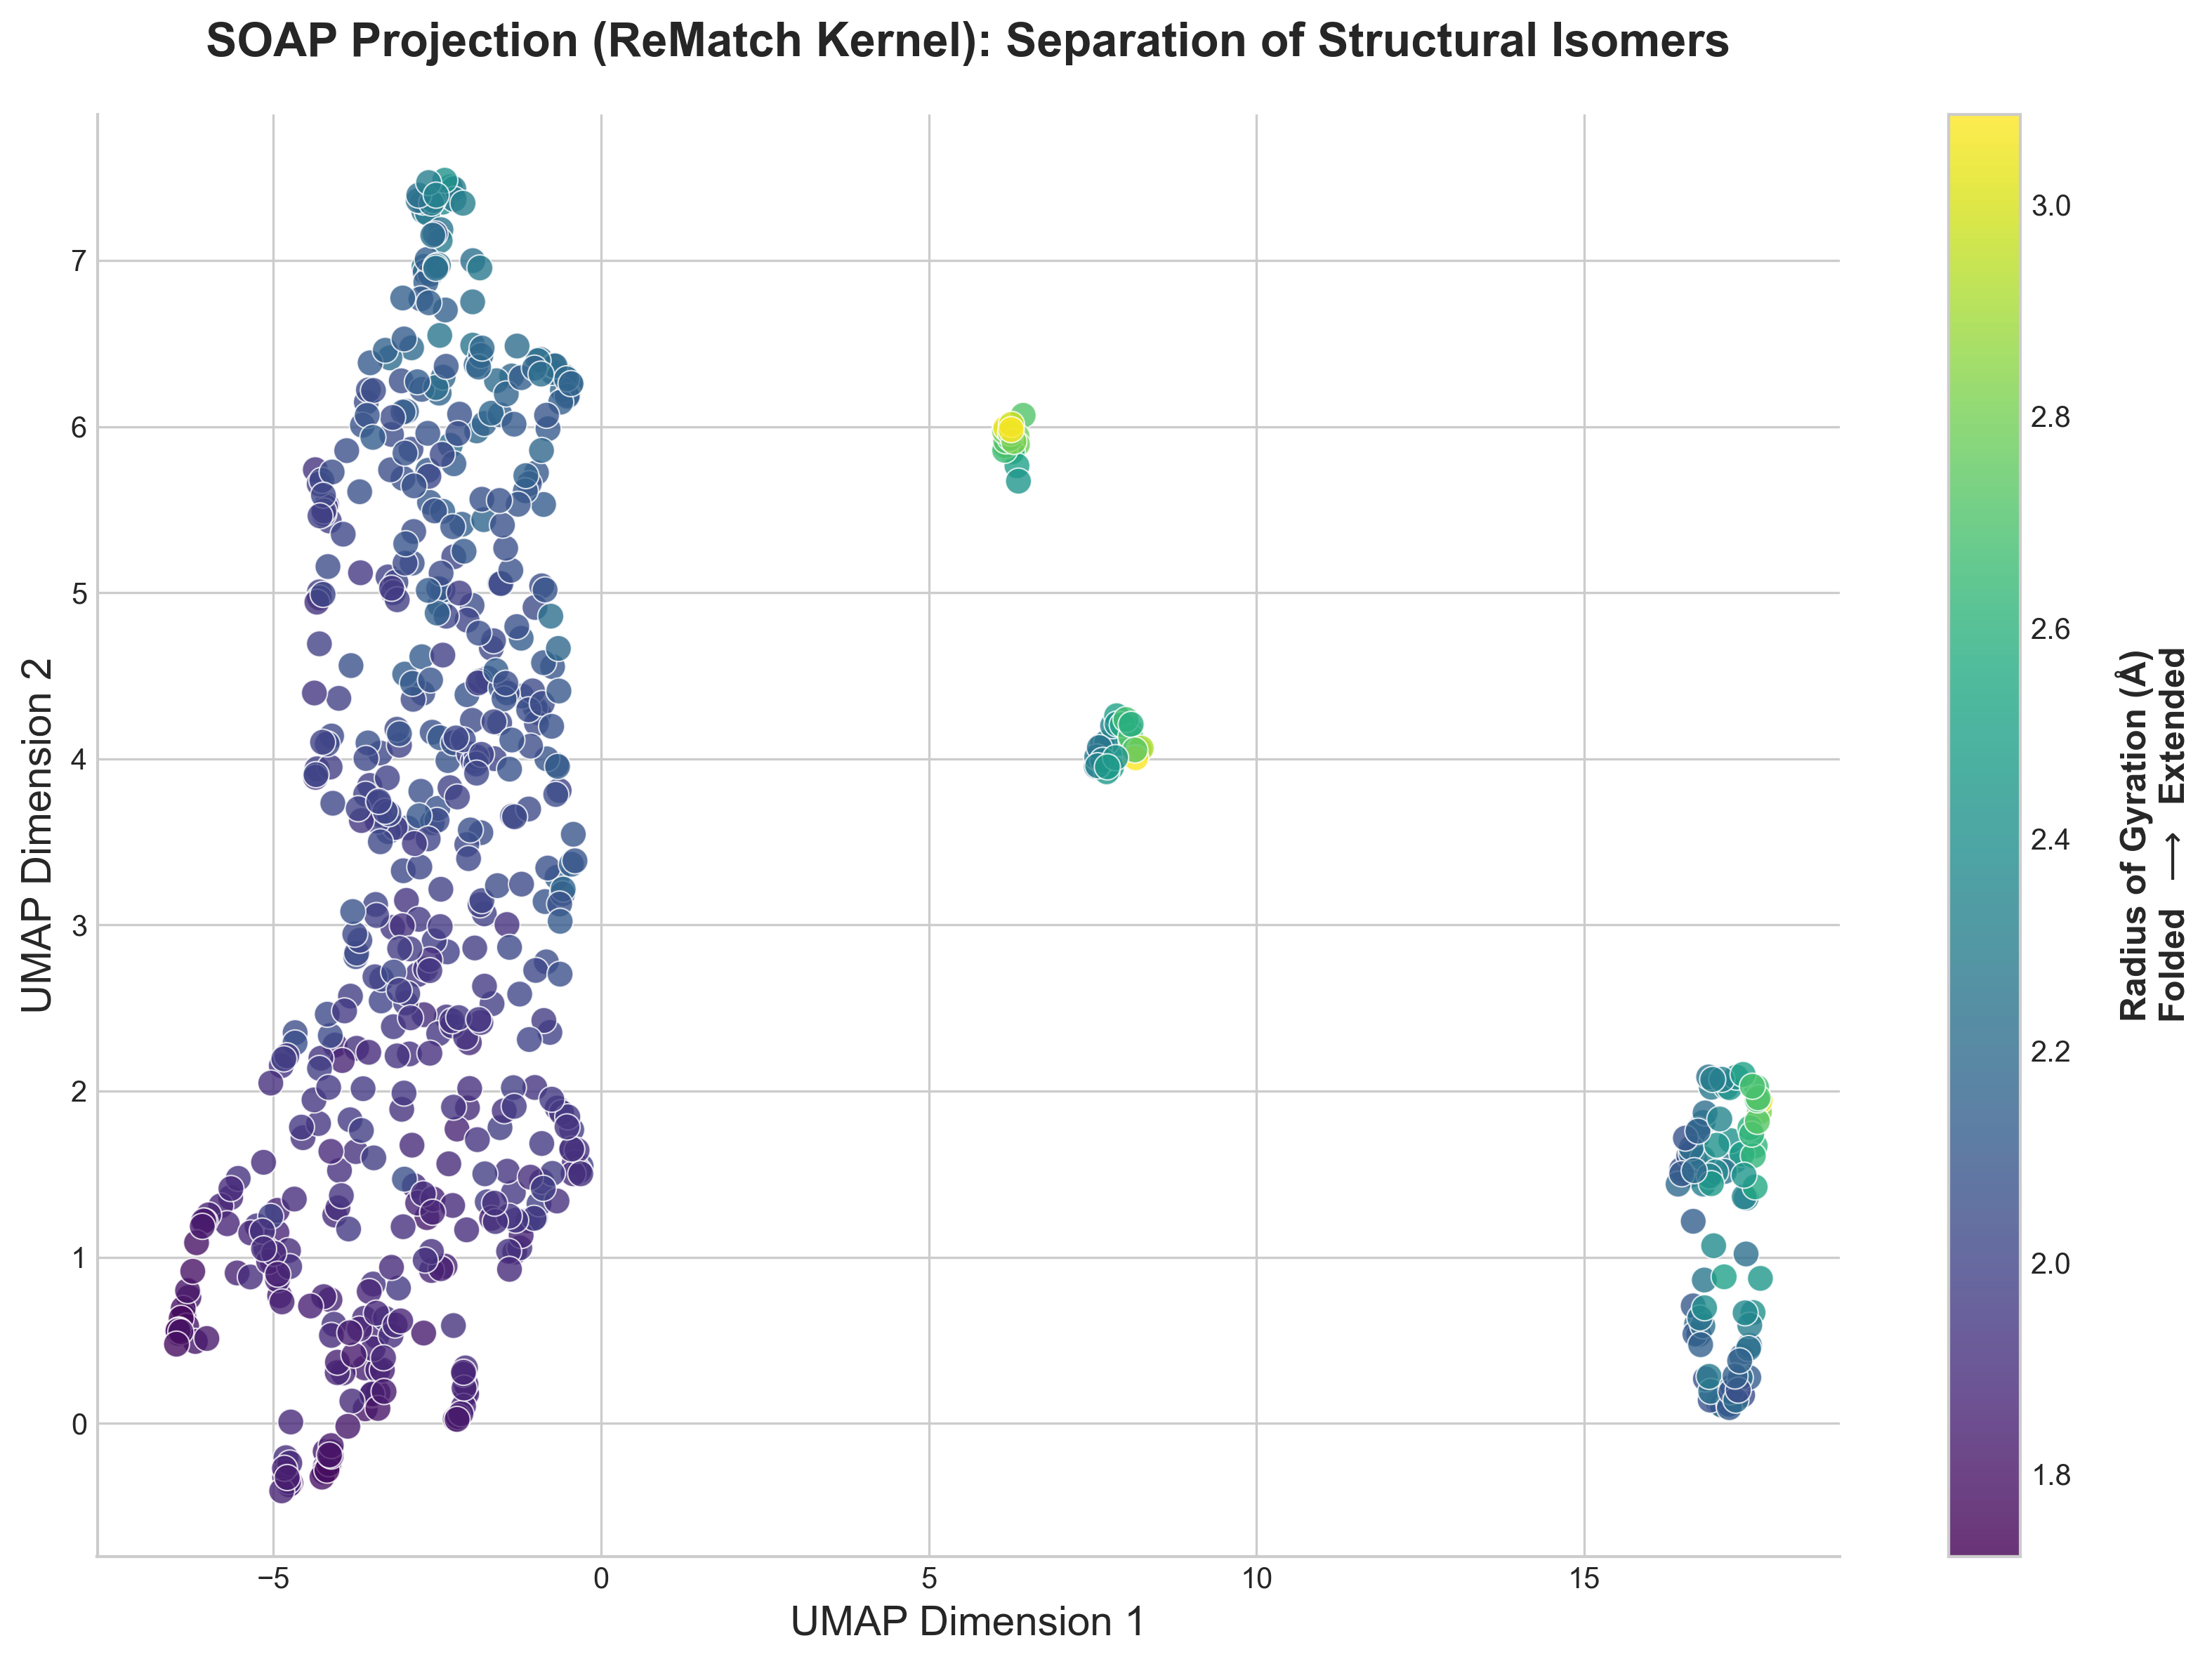

In [25]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(11, 8), dpi=300)

# Use ax.scatter directly, as it handles continuous colorbars better than sns.scatterplot
scatter = ax.scatter(
    x=plot_df["UMAP_1"], 
    y=plot_df["UMAP_2"], 
    c=plot_df["Radius_of_Gyration"], 
    cmap="viridis",   # Swapped from 'magma' to 'viridis' for the physical value scale
    s=80,             # Marker size
    alpha=0.8,        # Transparency to reveal density
    edgecolor='w',    # White border for crisp edges
    linewidth=0.5
)

# 5. Add the Colorbar and Labels
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Radius of Gyration (Å)\nFolded  $\longrightarrow$  Extended', fontsize=12, fontweight='bold', labelpad=15)

ax.set_title("SOAP Projection (ReMatch Kernel): Separation of Structural Isomers", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("UMAP Dimension 1", fontsize=14, fontweight='medium')
ax.set_ylabel("UMAP Dimension 2", fontsize=14, fontweight='medium')

# Clean up axes
sns.despine(fig)
plt.tight_layout()

plt.show()

In [ ]:
create_chemiscope_viewer(df_iso, dist_matrix, labels=[i for i in range(len(df_iso))], reduction_method='UMAP')

2026-05-19 10:49:40.649 | INFO     | src.helper_functions:create_chemiscope_viewer:1163 - Running UMAP dimensionality reduction...
2026-05-19 10:49:40.693 | INFO     | src.helper_functions:create_chemiscope_viewer:1172 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-19 10:50:02.036 | INFO     | src.helper_functions:create_chemiscope_viewer:1212 - Projecting using UMAP with n_neighbours = 15
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-19 10:50:02.805 | INFO     | src.helper_

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

# Hypothesis 2
- Molecules with 3 membered rings will be strained and have a different SOAP than molecules with a 6 membered ring.

In [5]:
def categorize_pure_carbocycle(smiles: str) -> str:
    """
    Parses a SMILES string. 
    Returns '3-ring' or '6-ring' ONLY if the ring is made entirely of Carbon.
    Rejects heterocycles (rings with O, N, F).
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or "O" in smiles or "N" in smiles:
        return "Other"
    
    # Get ring information
    ring_info = mol.GetRingInfo().AtomRings()
    
    # Reject acyclic molecules
    if not ring_info:
        return "Acyclic"
        
    # Check if ALL rings are pure Carbon (Atomic Number == 6)
    for ring in ring_info:
        for atom_idx in ring:
            atom = mol.GetAtomWithIdx(atom_idx)
            if atom.GetAtomicNum() != 6:
                return "Heterocycle" # Reject if the ring contains O, N, F, etc.
                
    # Extract unique ring sizes
    sizes = set(len(ring) for ring in ring_info)
    
    # Return valid pure carbocycles
    if sizes == {3}:
        return "3-ring"
    elif sizes == {6}:
        return "6-ring"
    else:
        return "Mixed/Other"

# 1. Apply the strict function
print("Categorizing rings and enforcing carbocycles using RDKit...")
df = df.with_columns(
    pl.col("smiles")
    .map_elements(categorize_pure_carbocycle, return_dtype=pl.Utf8)
    .alias("ring_category")
)

# 1. Start with the fully categorized dataset (NO heavy atom filter yet)
df_3_rings_all = df.filter(pl.col("ring_category") == "3-ring")
df_6_rings_all = df.filter(pl.col("ring_category") == "6-ring")

# 2. Count the occurrences of each formula in both groups
counts_3 = df_3_rings_all.group_by("formula").len().rename({"len": "count_3"})
counts_6 = df_6_rings_all.group_by("formula").len().rename({"len": "count_6"})

# 3. Join the counts to find formulas that exist in BOTH groups
formula_overlap = counts_3.join(counts_6, on="formula", how="inner")

# 4. Calculate the bottleneck (the maximum possible balanced sample size)
# The max size is constrained by whichever group has fewer molecules
formula_overlap = formula_overlap.with_columns(
    pl.min_horizontal("count_3", "count_6").alias("max_balanced_size")
).sort("max_balanced_size", descending=True)

# Let's see the top 5 formulas in the whole dataset for this experiment
print("Top 5 optimal formulas for the strain experiment:")
print(formula_overlap.head(10))

# 5. Extract the absolute best formula
if formula_overlap.height == 0:
    raise ValueError("No shared formulas found in the dataset!")

best_row = formula_overlap.row(0, named=True)
best_formula = best_row["formula"]
max_size = best_row["max_balanced_size"]

print(f"\nStrict Control Triggered: Restricting entire experiment to {best_formula}")
print(f"This allows for a perfectly balanced dataset of {max_size} vs {max_size} molecules.")

# 6. Create the final perfectly balanced dataset
df_3_sampled = df_3_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)
df_6_sampled = df_6_rings_all.filter(pl.col("formula") == best_formula).sample(n=max_size, seed=42)

df_strain_experiment = pl.concat([df_3_sampled, df_6_sampled])
print(f"Final experimental dataset shape: {df_strain_experiment.height} molecules.")

Categorizing rings and enforcing carbocycles using RDKit...
Top 5 optimal formulas for the strain experiment:
shape: (10, 4)
┌─────────┬─────────┬─────────┬───────────────────┐
│ formula ┆ count_3 ┆ count_6 ┆ max_balanced_size │
│ ---     ┆ ---     ┆ ---     ┆ ---               │
│ str     ┆ u32     ┆ u32     ┆ u32               │
╞═════════╪═════════╪═════════╪═══════════════════╡
│ C9H16   ┆ 27      ┆ 31      ┆ 27                │
│ C9H12   ┆ 12      ┆ 23      ┆ 12                │
│ C9H14   ┆ 71      ┆ 7       ┆ 7                 │
│ C9H18   ┆ 57      ┆ 5       ┆ 5                 │
│ C8H14   ┆ 6       ┆ 5       ┆ 5                 │
│ C8H16   ┆ 23      ┆ 3       ┆ 3                 │
│ C7H12   ┆ 2       ┆ 2       ┆ 2                 │
│ C8H10   ┆ 2       ┆ 7       ┆ 2                 │
│ C8H12   ┆ 19      ┆ 2       ┆ 2                 │
│ C6H12   ┆ 4       ┆ 1       ┆ 1                 │
└─────────┴─────────┴─────────┴───────────────────┘

Strict Control Triggered: Restricting enti

In [10]:
soap_matrices = df_strain_experiment['soap_matrix'].to_list()

# 2. Initialize the REMatch Kernel
# You MUST define the base metric and the entropy regularization parameter.
kernel = REMatchKernel(
    metric="linear",  # Base kernel to compare individual atomic environments
    alpha=0.1        # Entropy regularization (Sinkhorn parameter)
)

df_strain_experiment = df_strain_experiment.with_columns(
    ring_labels = pl.when(pl.col("ring_category") == "3-ring")
                    .then(3)
                    .otherwise(6)
)

# 3. Compute the N x N Kernel Similarity Matrix
print("Computing REMatch kernel matrix...")
kernel_matrix = kernel.create(soap_matrices)

# 4. Convert Kernel Matrix to Distance Matrix (Your perfect code)
diag = np.diag(kernel_matrix)
dist_sq = diag[:, None] + diag[None, :] - 2.0 * kernel_matrix
dist_sq = np.clip(dist_sq, a_min=0.0, a_max=None)
dist_matrix = np.sqrt(dist_sq)

# Eliminate floating point artifacts on diagonals and force strict symmetry
np.fill_diagonal(dist_matrix, 0.0)
dist_matrix = (dist_matrix + dist_matrix.T) / 2.0

Computing REMatch kernel matrix...


In [29]:
create_chemiscope_viewer(df_strain_experiment, dist_matrix, labels=df_strain_experiment['ring_labels'].to_list(), reduction_method='UMAP')

2026-05-25 15:37:33.282 | INFO     | src.helper_functions:create_chemiscope_viewer:1163 - Running UMAP dimensionality reduction...
2026-05-25 15:37:33.287 | INFO     | src.helper_functions:create_chemiscope_viewer:1172 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-25 15:37:33.514 | INFO     | src.helper_functions:create_chemiscope_viewer:1212 - Projecting using UMAP with n_neighbours = 5
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-25 15:37:33.545 | INFO     | src.helper_f

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …

In [7]:
import numpy as np
from umap import UMAP
from sklearn.metrics import silhouette_score
ring_labels_raw = df_strain_experiment["ring_labels"].to_numpy()
legend_labels = [
    "Strained (3-Membered)" if val == 3 else "Relaxed (6-Membered)"
    for val in ring_labels_raw
]


# Convert labels to integers (required for silhouette)
labels = ring_labels_raw  # or df_strain_experiment["ring_labels"].to_numpy()

# If binary:
# labels = np.array([0 if x == 3 else 1 for x in ring_labels_raw])

# Or more robust mapping:
unique_labels = np.unique(labels)
label_to_int = {v: i for i, v in enumerate(unique_labels)}
y = np.array([label_to_int[v] for v in labels])

def evaluate_n_neighbors(n, dist_matrix, y):
    reducer = UMAP(
        n_neighbors=n,
        metric="precomputed",
        random_state=42
    )
    embedding = reducer.fit_transform(dist_matrix)

    score = silhouette_score(embedding, y, metric="euclidean")
    return score, embedding

# Sweep range (log-ish spacing is often better for UMAP)
n_values = list(range(2, 51))  # adjust as needed

scores = []
best_score = -1
best_n = None
best_embedding = None

print("Optimizing n_neighbors...\n")

for n in n_values:
    score, embedding = evaluate_n_neighbors(n, dist_matrix, y)
    scores.append(score)

    print(f"n_neighbors={n:2d} | silhouette={score:.4f}")

    if score > best_score:
        best_score = score
        best_n = n
        best_embedding = embedding

print("\n========================")
print(f"Best n_neighbors: {best_n}")
print(f"Best silhouette:   {best_score:.4f}")
print("========================")

Optimizing n_neighbors...



/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


n_neighbors= 2 | silhouette=0.1967
n_neighbors= 3 | silhouette=0.7363
n_neighbors= 4 | silhouette=0.6239
n_neighbors= 5 | silhouette=0.3915
n_neighbors= 6 | silhouette=0.4682
n_neighbors= 7 | silhouette=0.3336
n_neighbors= 8 | silhouette=0.2950
n_neighbors= 9 | silhouette=0.2611


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden t

n_neighbors=10 | silhouette=0.2934
n_neighbors=11 | silhouette=0.2569
n_neighbors=12 | silhouette=0.2687
n_neighbors=13 | silhouette=0.2364
n_neighbors=14 | silhouette=0.2074


...

n_neighbors=43 | silhouette=0.2421
n_neighbors=44 | silhouette=0.0985
n_neighbors=45 | silhouette=0.1946
n_neighbors=46 | silhouette=0.2415


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden t

n_neighbors=47 | silhouette=0.2037
n_neighbors=48 | silhouette=0.2532
n_neighbors=49 | silhouette=0.2846


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden t

n_neighbors=50 | silhouette=0.1498

Best n_neighbors: 3
Best silhouette:   0.7363


Computing UMAP projection from precomputed distance matrix...


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved high-res plot to soap_strain_hypothesis.png


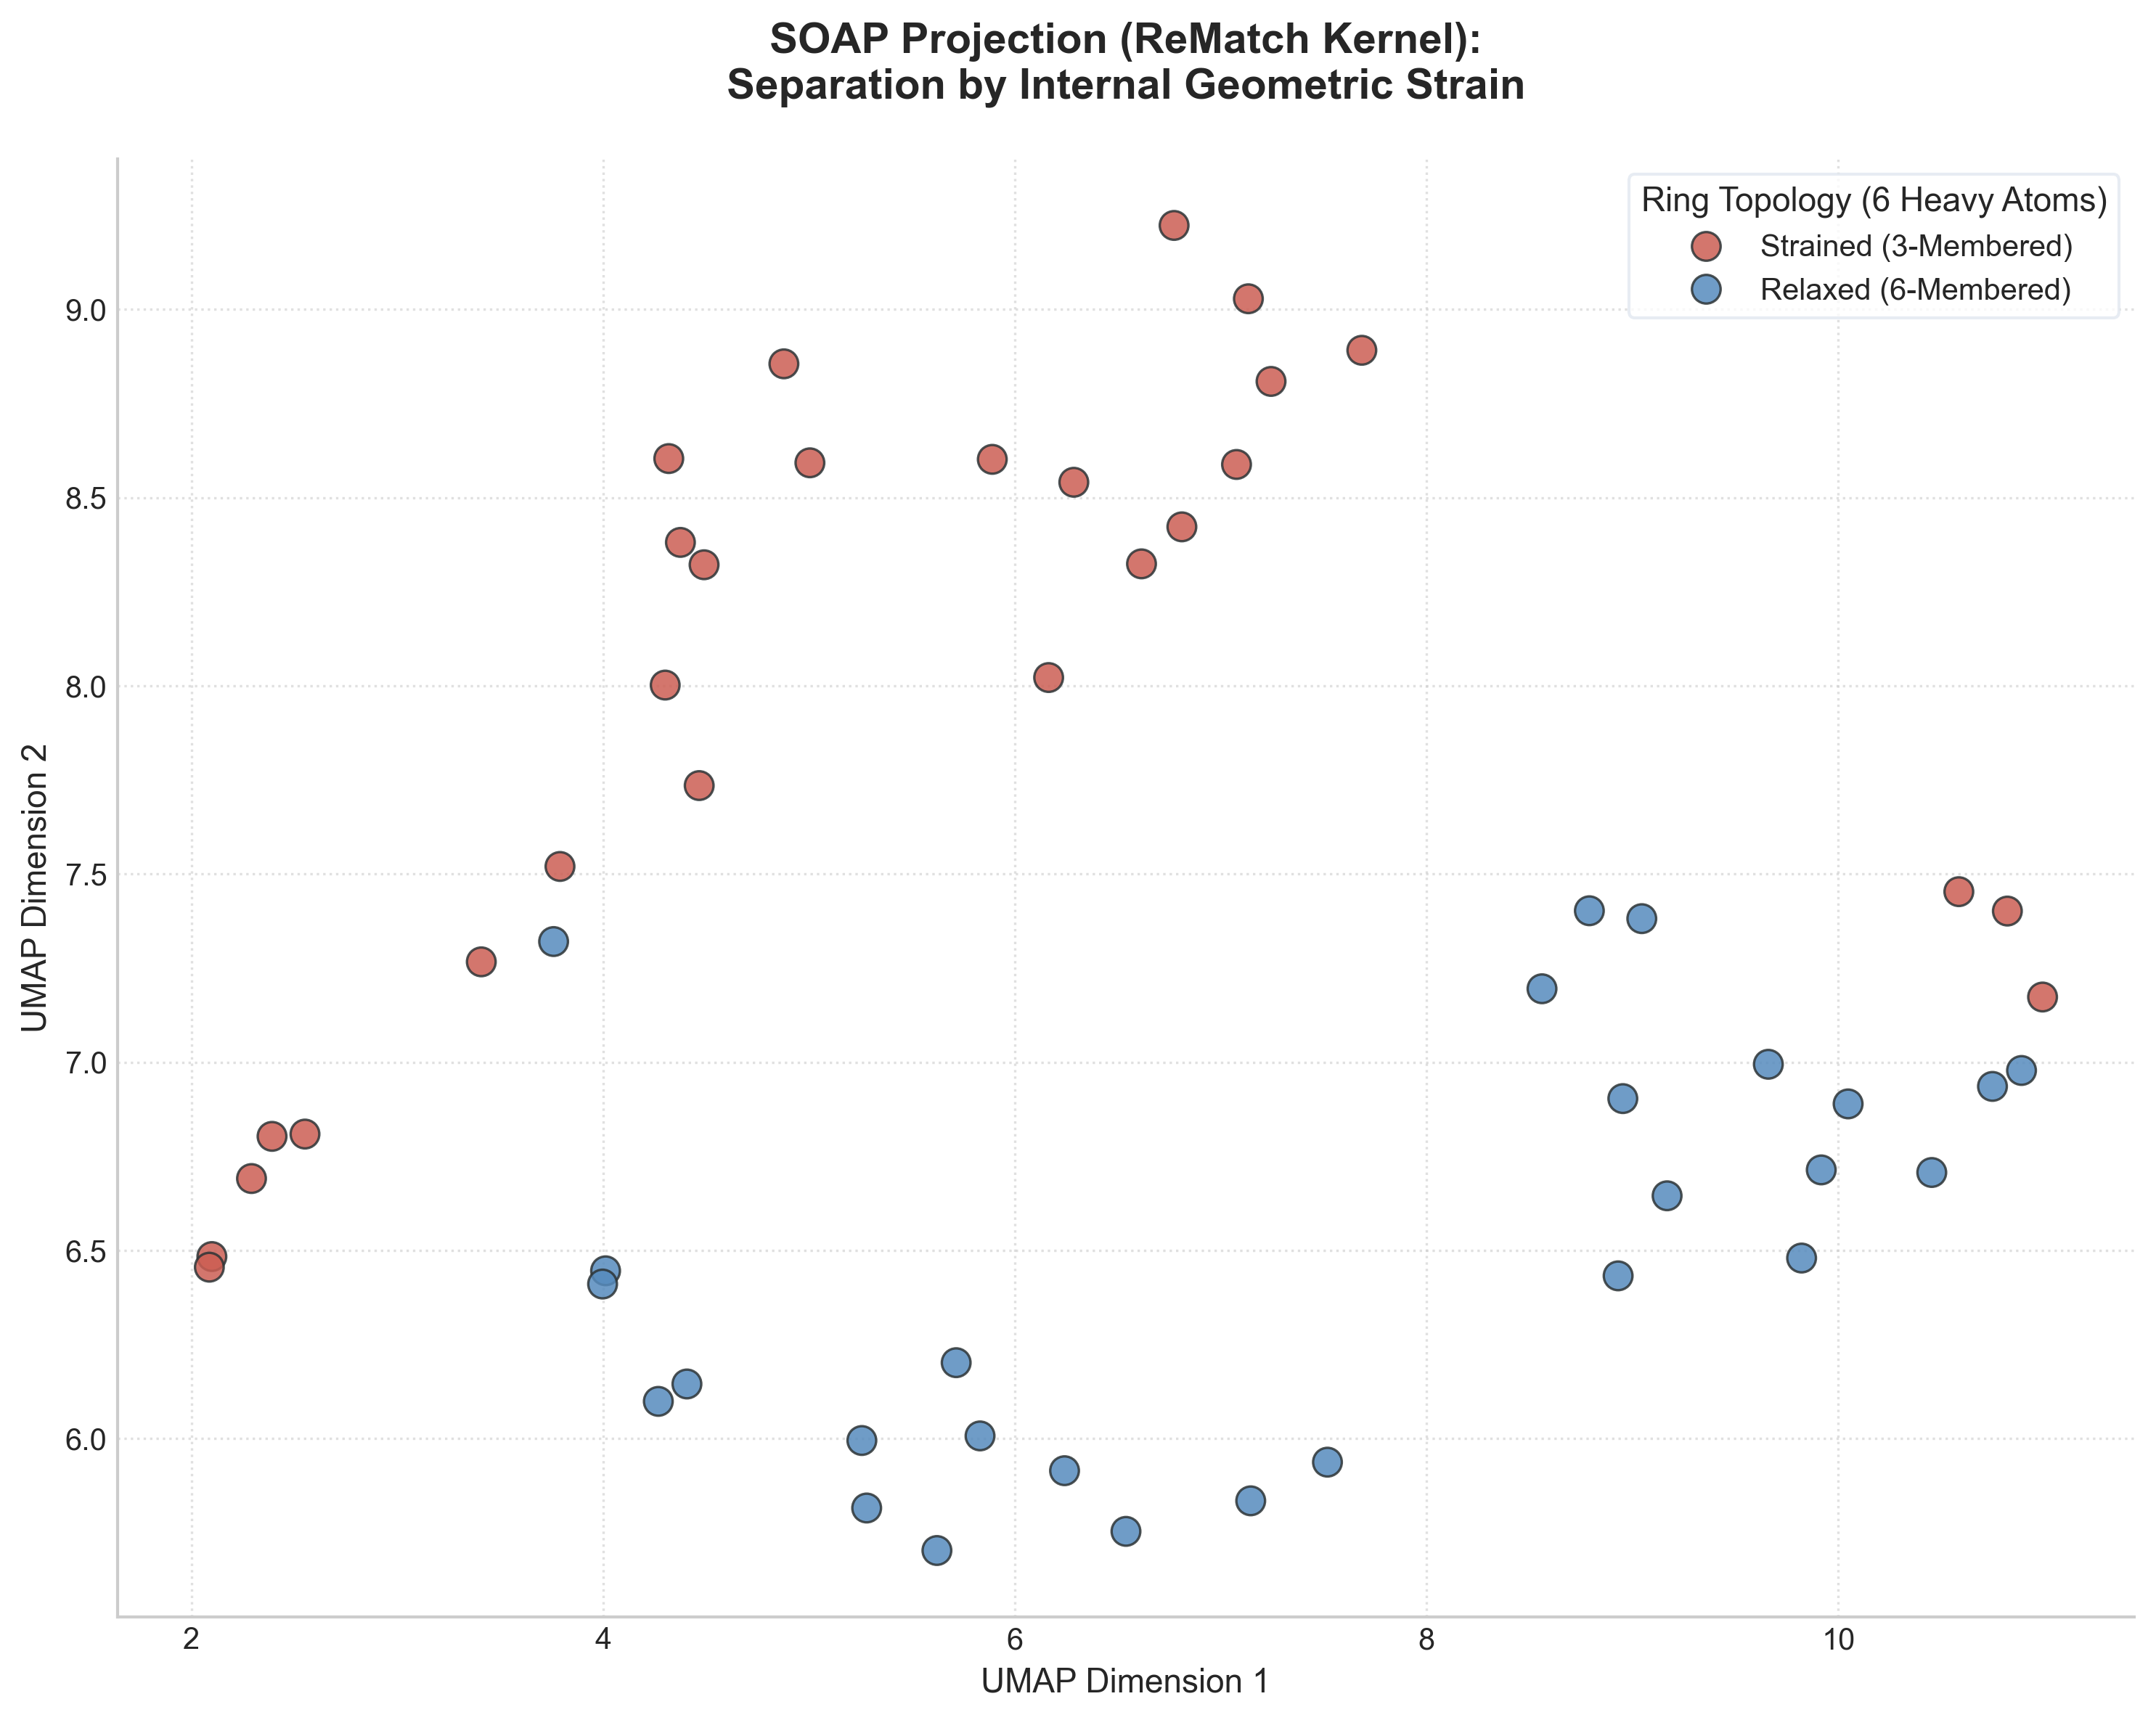

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from umap import UMAP

# =============================================================================
# 1. COMPUTE UMAP PROJECTION (Precomputed Latent Distance Matrix)
# =============================================================================
print("Computing UMAP projection from precomputed distance matrix...")
reducer = UMAP(n_neighbors=5, metric="precomputed", random_state=42)
umap_coords = reducer.fit_transform(dist_matrix)

# Map raw ring sizes to report-ready descriptive strings for the legend

# =============================================================================
# 2. GENERATE REPORT-THEMED GRAPH
# =============================================================================
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

# Exact matching report palette for internal geometric strain split
palette = {"Strained (3-Membered)": "#cc5e53", "Relaxed (6-Membered)": "#568bbd"}

sns.scatterplot(
    x=umap_coords[:, 0],
    y=umap_coords[:, 1],
    hue=legend_labels,
    palette=palette,
    s=90,  # Unified marker size matching your other figures
    alpha=0.85,  # Transparency configuration to reveal overlapping density
    edgecolors="#2d3436",  # Clean dark borders for crisp geometric boundaries
    linewidths=0.8,
    ax=ax,
    zorder=10,
)

# =============================================================================
# 3. STYLING, AXES, AND LEGEND CLEANUP
# =============================================================================
ax.set_title(
    "SOAP Projection (ReMatch Kernel):\nSeparation by Internal Geometric Strain",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("UMAP Dimension 1", fontsize=11, fontweight="medium")
ax.set_ylabel("UMAP Dimension 2", fontsize=11, fontweight="medium")

# Apply consistent faint dotted grid profile
ax.grid(True, linestyle=":", alpha=0.6)

# Format legend to blend seamlessly without bulky shadows
ax.legend(
    title="Ring Topology (6 Heavy Atoms)",
    title_fontsize=11,
    fontsize=10,
    loc="best",
    frameon=True,
    facecolor="white",
    edgecolor="#e2e8f0",
)

# Strip top and right borders
sns.despine(ax=ax)
plt.tight_layout()

# =============================================================================
# 4. EXPORT ARTIFACT
# =============================================================================
plt.savefig(
    "soap_strain_hypothesis.png", format="png", dpi=300, bbox_inches="tight"
)
print("Saved high-res plot to soap_strain_hypothesis.png")
plt.show()